In [ ]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from scipy.integrate import quad
from scipy import integrate as intg
import sympy as sp
from scipy import stats
from scipy.interpolate import UnivariateSpline
import pandas as pd
from scipy.stats import linregress
from scipy.stats import norm
import os
import seaborn as sns
from matplotlib import pyplot as plt, patches
import scipy
rng = np.random.default_rng()

from scipy.interpolate import CubicSpline

In [ ]:
color1,color2,color3,color4 = '#D76A03','#4169E1','#a52422','#8EA604'

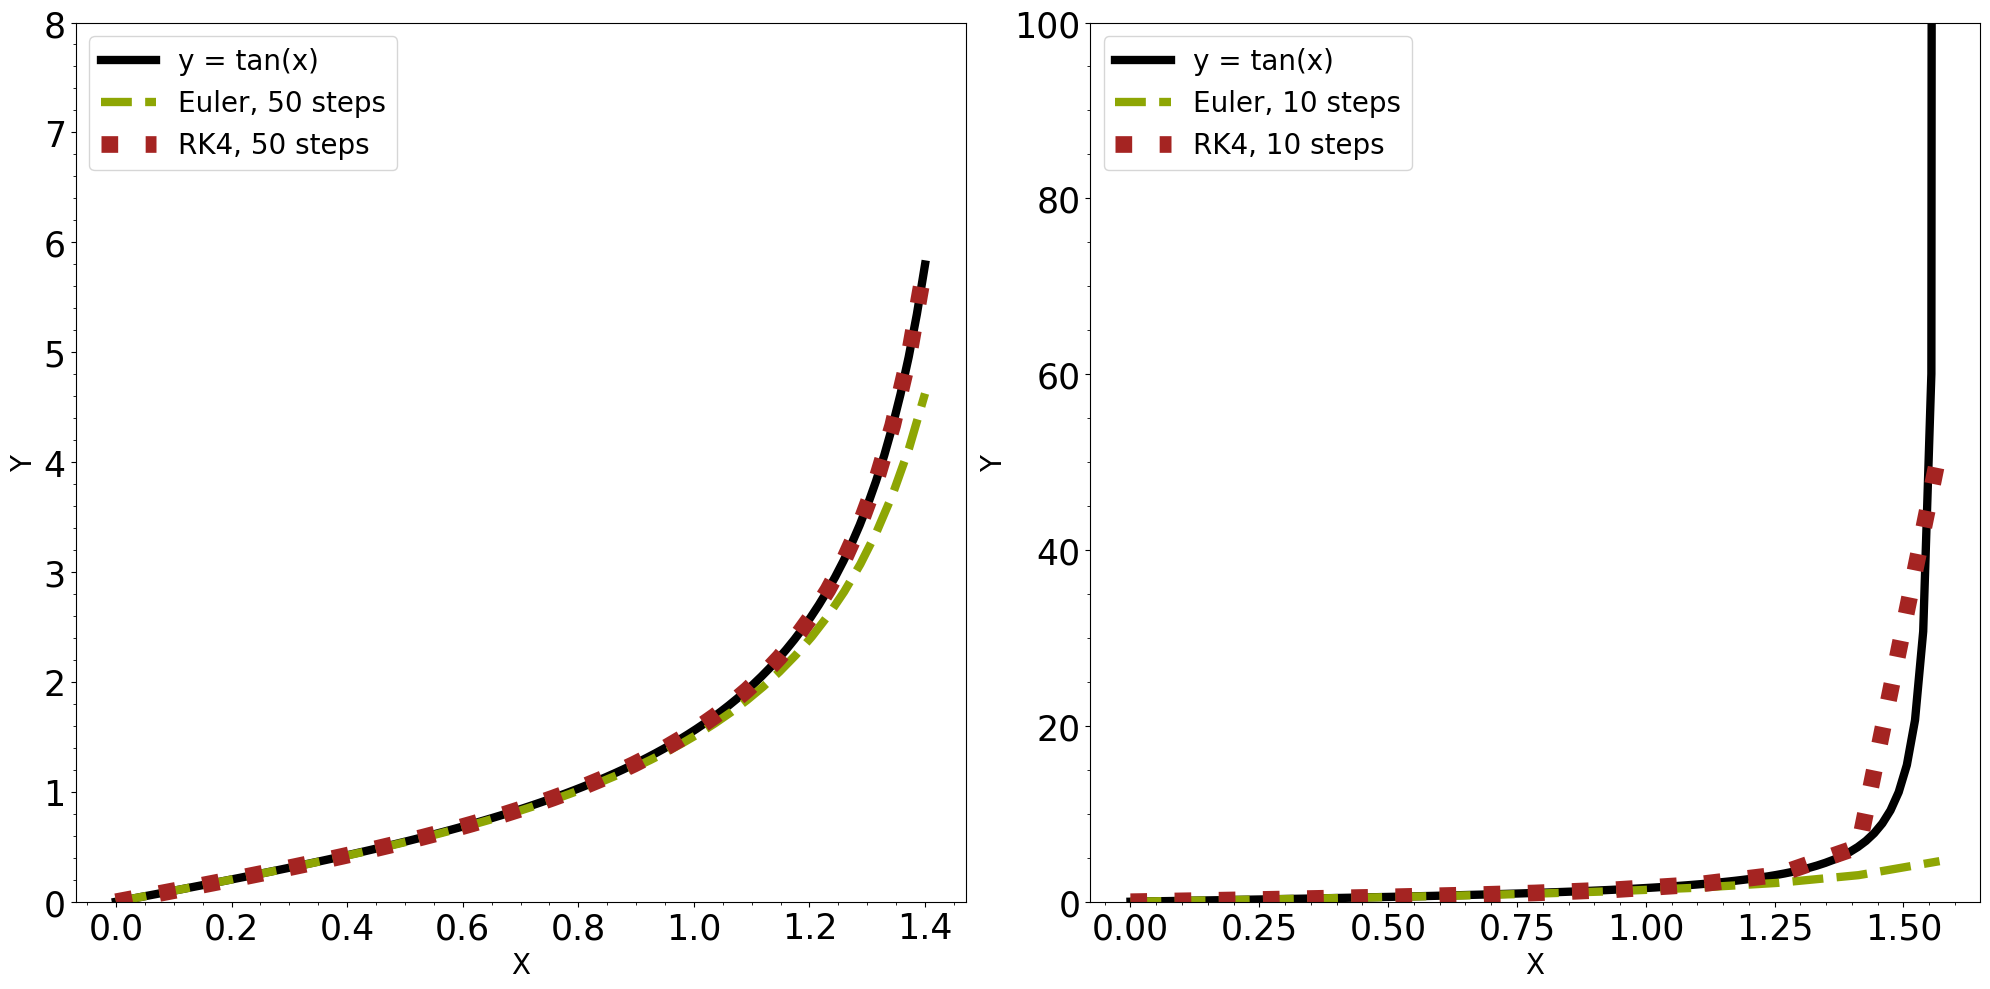

In [ ]:
#Problem 1, solving dy/dx = y**2+1 (should have exact soln of tan(x))

ARRR1 = []
BRRR1 = []

def prob1func (x,y):
  return (y**2)+1


def TanFunc (x):
  y = np.tan(x)
  return y

def EulerTest(x0, y0, xn, n):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    # Simple Euler step
    for i in range(n):
        y0 += h * prob1func(x0, y0)
        x0 += h
        ARRR1.append(x0)
        BRRR1.append(y0)

    return ARRR1, BRRR1
def RKtest(x0, y0, xn, n,function):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    for i in range(n):
        k1 = h * function(x0, y0)
        k2 = h * function(x0 + h/2, y0 + k1/2)
        k3 = h * function(x0 + h/2, y0 + k2/2)
        k4 = h * function(x0 + h, y0 + k3)

        k = (k1 + 2*k2 + 2*k3 + k4) / 6
        y0 = y0 + k
        x0 = x0 + h

        ARRR1.append(x0)
        BRRR1.append(y0)

    return ARRR1, BRRR1

#result1 = RKtest(0,1,10,100)
#the solution is 2nd item in the array (or the [1] ojbject in array)
#print (result1[1])

#print ((ARRR1,BRRR1))
#plt.plot(ARRR1,BRRR1)


#x0 is the
x0_break, y0 = 0, 0.0
x0 = 0
x_e1, y_e1 = EulerTest(x0, y0, 1.4, 50)
x_rk1, y_rk1 = RKtest(x0, y0, 1.4, 50, prob1func)
x_ex1 = np.linspace(x0, 1.4, 100)
y_ex1 = TanFunc(x_ex1)

# Breakdown range
xn_break = 1.569999988888
n_break = 10
x_e2, y_e2 = EulerTest(x0, y0, xn_break, n_break)
x_rk2, y_rk2 = RKtest(x0, y0, xn_break, n_break, prob1func)
x_ex2 = np.linspace(x0, xn_break, 100)
y_ex2 = TanFunc(x_ex2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.plot(x_ex1, y_ex1, 'k-', linewidth=6, label='y = tan(x)')
ax1.plot(x_e1, y_e1, color=color4, linestyle='--', linewidth=6, label='Euler, 50 steps')
#ax1.plot(x_rk1, y_ex1,linewidth=2, label='RK4')

ax1.plot(x_rk1, y_rk1, color='#a52422', linestyle='dotted', linewidth=12, label='RK4, 50 steps')



ax1.set_ylim(0, 8)
ax1.set_xlabel("X", fontsize=20)
ax1.set_ylabel("Y", fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.legend(loc='upper left', fontsize=20)
ax1.minorticks_on()



ax2.plot(x_ex2, y_ex2, 'k-', linewidth=6, label='y = tan(x)')
ax2.plot(x_e2, y_e2, color=color4, linestyle='--', linewidth=6, label='Euler, 10 steps')
ax2.plot(x_rk2, y_rk2, color='#a52422', linestyle='dotted', linewidth=12, label='RK4, 10 steps')





ax2.set_ylim(0, 100)
ax2.set_xlabel("X", fontsize=20)
ax2.set_ylabel("Y", fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=25)
ax2.legend(loc='upper left', fontsize=20)
ax2.minorticks_on()

#plt.savefig('Fig1',dpi = 300)
plt.tight_layout()
plt.show()

plt.show()

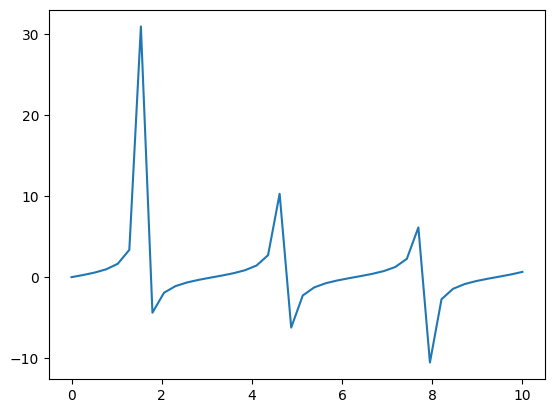

In [ ]:
#This plot didnt end up being useful because the function breaks down at 1.5666, But if we needed to be accurate over more of the tan(x) range this is what  I would have usded

x = np.linspace(0,10,40)
#print (x)
plt.plot(x, TanFunc(x))

In [ ]:

#sampling different log values
n_vals = np.array([10, 20, 40, 80, 160, 320, 640])
n_best = 1280
x_test = 1.4

x_e_best, y_e_best = EulerTest(0, 0, x_test, n_best)
x_rk_best, y_rk_best = RKtest(0, 0, x_test, n_best, prob1func)

best_e = y_e_best[-1]
best_rk = y_rk_best[-1]

h_vals = []
e_diffs = []
rk_diffs = []

# Calc diffs
for n in n_vals:
    h_vals.append(x_test / n)

    x_e, y_e = EulerTest(0, 0, x_test, n)
    x_rk, y_rk = RKtest(0, 0, x_test, n, prob1func)

    e_diffs.append(abs(y_e[-1] - best_e) / abs(best_e))

    rk_diffs.append(abs(y_rk[-1] - best_rk) / abs(best_rk))



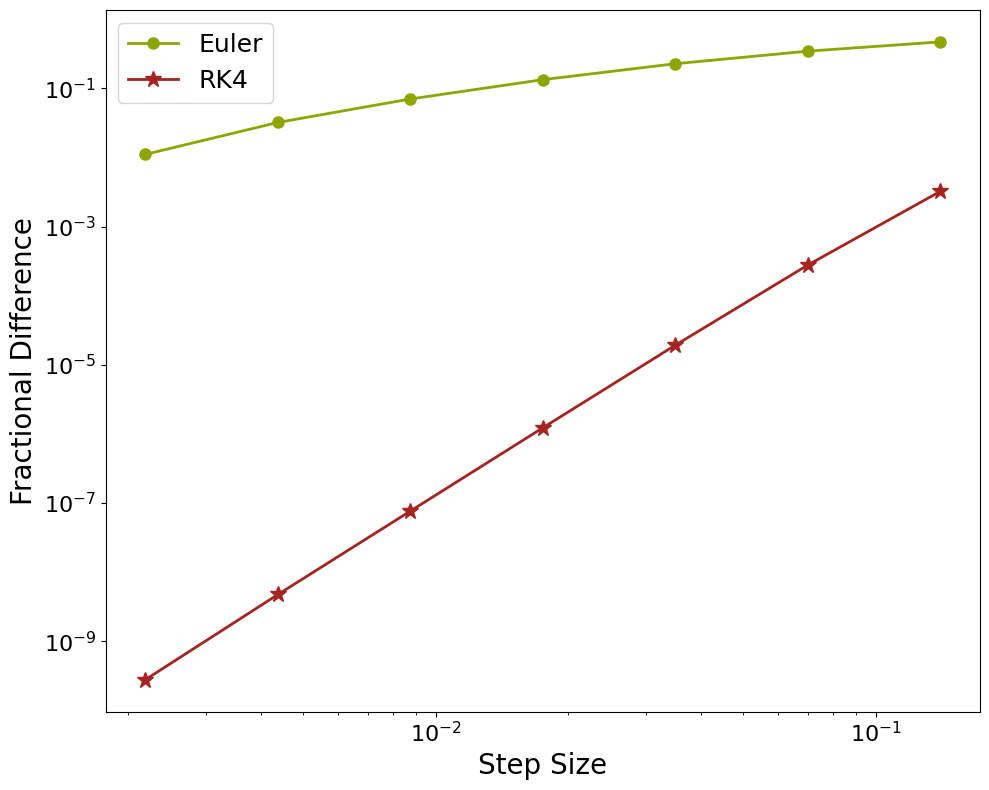

In [ ]:


fig, ax = plt.subplots(figsize=(10, 8))

ax.loglog(h_vals, e_diffs, marker='o', color=color4, markersize=8, linewidth=2, label='Euler')
ax.loglog(h_vals, rk_diffs, marker='*', color=color3, markersize=12, linewidth=2, label='RK4')

#Trying to get linear (10,100,1000 values on x axis with this, but idk if it works)
#ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#ax.ticklabel_format(scilimits=(-2,2), useMathText=True)


ax.set_xlabel("Step Size", fontsize=20)
ax.set_ylabel("Fractional Difference", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=18)

plt.tight_layout()
plt.show()

In [ ]:
:##Prob 1 D, increasing/decreasing step size

y_exact_val = TanFunc(x_test)

est_err_e = e_diffs[-1]
est_err_rk = rk_diffs[-1]

act_err_e = abs(best_e - y_exact_val) / abs(y_exact_val)
act_err_rk = abs(best_rk - y_exact_val) / abs(y_exact_val)

# Compare errors
print(f"Euler error comparison: {est_err_e:.4e} | actual error: {act_err_e:.4e}")
print(f"RK4 error comparison:   {est_err_rk:.4e} | actual erro: {act_err_rk:.4e}")

Euler error comparison: 1.1068e-02 | actual error: 1.1356e-02
RK4 error comparison:   2.7898e-10 | actual erro: 1.8557e-11


In [ ]:
#seeing what scipy gives
#ytest = TanFunc(1)
#print (ytest)
#integr_test = scipy.integrate.RK45(TanFunc,1,ytest,1)

In [ ]:
#Defining some constants
#Temp = 273.15 #This is temp at stp, but we only really care at 10,000... Prob dont need to use this except as sanity check
k = 1.380649*(10**-23)
v = np.linspace(0, 300, 100)  # going from 0-1000m/s
#v = np.linspace(0, 200, 100)
def Maxwell(T,M):
  return ((np.abs(M/(2*np.pi*k*T)))**(3/2))*(4*(np.pi)*(v**2))*(np.exp(-(M*v**2)/(2*k*T)))




test123 = Maxwell(10000,6.02*(10**-23))
fig, ax = plt.subplots(figsize=(10, 8))
testlowtemp = Maxwell(1000,6.02*(10**-23))
testhightemp = Maxwell(20000,6.02*(10**-23))
#print (testhightemp.max())
#print (test123)
plt.scatter(v,test123, color = color1,marker='.',s = 100,label ="Maxwell-Boltzman Velocity: T= 10,000K")
plt.scatter(v,testlowtemp, color = color2,marker='^',s = 50,label ="Maxwell-Boltzman Velocity: T= 1,000K")
plt.scatter(v,testhightemp, color = color3,marker='D',s = 20,label ="Maxwell-Boltzman Velocity: T= 20,000K")


ax.set_xlabel("Velocity [m/s]", fontsize=20)
ax.set_ylabel("f(v)dv", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
plt.axvline(x=67.5, color='k', linestyle='--', label = 'T=10,000K peak')
ax.legend(fontsize=18)
plt.tight_layout()
#plt.savefig('fig3', dpi = 300)
plt.show()

# Question 2 Maxwell botlzman distribution
f(f) dv or can be f(v) = f_v, but it is just df/dv where f is the probability function per dv... so f(v) is our pdf (prob density function) and the f in df/dv is the probability (an integrated quanituty.

Part. you should plot f and it hsould be somewhat gaussian with an exponeital tail


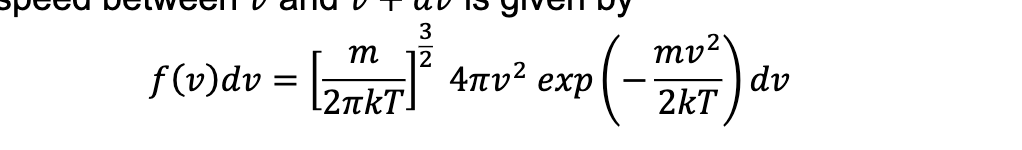

12851.046724445274


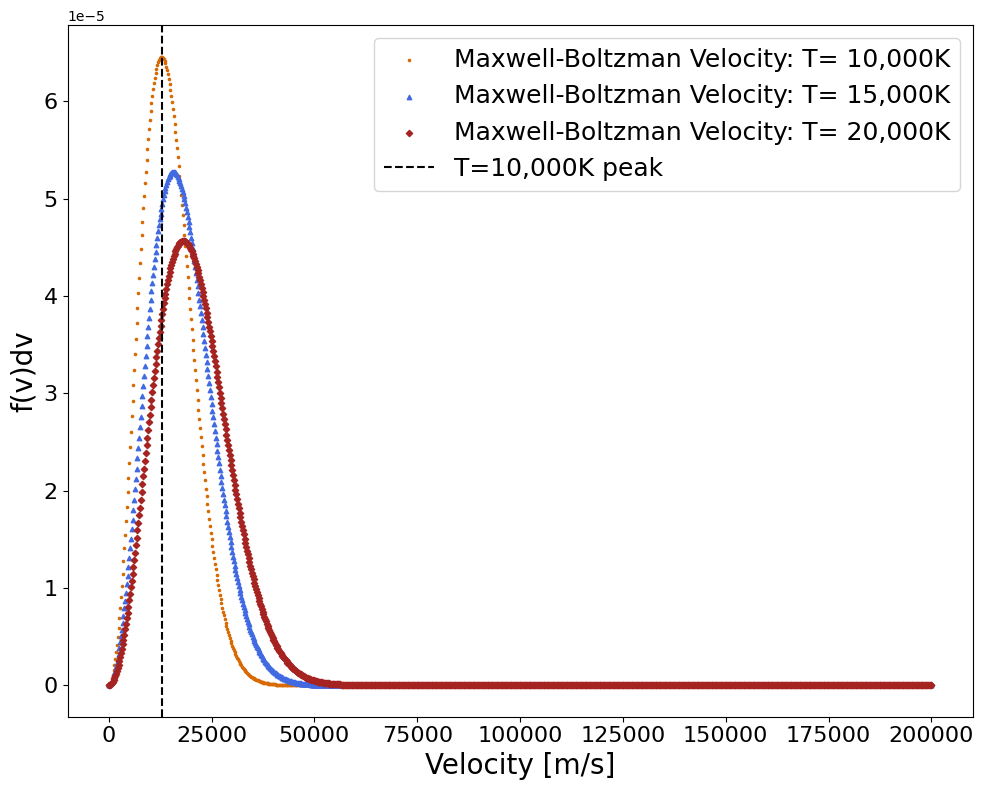

In [ ]:

#Defining some constants
k = 1.380649*(10**-23)
m = 1.672*(10**-27)


def Maxwell(v_curr, T, M):
  term1 = (np.abs(M/(2*np.pi*k*T)))**(3/2)
  term2 = 4*(np.pi)*(v_curr**2)
  term3 = np.exp(-(M*v_curr**2)/(2*k*T))
  return term1 * term2 * term3

v_plot = np.linspace(0, 200000, 1000)

fig, ax = plt.subplots(figsize=(10, 8))


test123 = Maxwell(v_plot, 10000, m)
testlowtemp = Maxwell(v_plot, 15000, m)
testhightemp = Maxwell(v_plot, 20000, m)

plt.scatter(v_plot, test123, color = '#D76A03', marker='.', s = 10, label ="Maxwell-Boltzman Velocity: T= 10,000K")
plt.scatter(v_plot, testlowtemp, color = '#4169E1', marker='^', s = 10, label ="Maxwell-Boltzman Velocity: T= 15,000K")
plt.scatter(v_plot, testhightemp, color = '#a52422', marker='D', s = 10, label ="Maxwell-Boltzman Velocity: T= 20,000K")

peak_velocity_10000K = np.sqrt(2 * k * 10000 / m) #my value of 12851 is quite cclose to the hyperphysics calculator value of 12844, prob close enough
print (peak_velocity_10000K)
plt.axvline(x=peak_velocity_10000K, color='k', linestyle='--', label = 'T=10,000K peak')

ax.set_xlabel("Velocity [m/s]", fontsize=20)
ax.set_ylabel("f(v)dv", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=18)



plt.tight_layout()
plt.savefig('fig3',dpi =300)
plt.show()

In [ ]:
#No clue what a reasonable value for "infinity" is, but the code starts to take incredibly long after about 500k, so ill just do 250k
def Maxwell_RK(v, y):
    return Maxwell(v, T, m)

v_infs = [100000, 150000, 250000]
steps_list = [100, 500, 2500, 12500]

v_best, F_best = RKtest(v_min, 0.0, 250000, 12000, Maxwell_RK)
best_val = F_best[-1]

print(f"{'v_inf (m/s)':<15} | {'Steps':<10} | {'Fraction':<15} | {'Diff from Best'}")

for v_inf_curr in v_infs:
    for n_steps_curr in steps_list:
        v_curr, F_curr = RKtest(v_min, 0.0, v_inf_curr, n_steps_curr, Maxwell_RK)
        curr_val = F_curr[-1]

        diff = abs(curr_val - best_val) / abs(best_val)
        print(f"{v_inf_curr:<15.1f} | {n_steps_curr:<10} | {curr_val:<15.4e} | {diff:<.4e}")

v_inf (m/s)     | Steps      | Fraction        | Diff from Best
100000.0        | 100        | 2.9265e-05      | 1.7008e-06
100000.0        | 500        | 2.9265e-05      | 2.7233e-09
100000.0        | 2500       | 2.9265e-05      | 3.0193e-12
100000.0        | 12500      | 2.9265e-05      | 1.3429e-12
150000.0        | 100        | 2.9265e-05      | 2.1914e-05
150000.0        | 500        | 2.9265e-05      | 3.5221e-08
150000.0        | 2500       | 2.9265e-05      | 5.5001e-11
150000.0        | 12500      | 2.9265e-05      | 1.2828e-12
250000.0        | 100        | 2.9274e-05      | 3.0969e-04
250000.0        | 500        | 2.9265e-05      | 5.0410e-07
250000.0        | 2500       | 2.9265e-05      | 8.0574e-10
250000.0        | 12500      | 2.9265e-05      | 8.6832e-14
